# DSCI 552 Homework 2 - Jazmine Tabora

##### due September 25, 2026 11:59 PM

## 1. Combined Cycle Power Plant Data Set

### (a) Download data set - COMPLETED

### (b) Exploring the data:

#### i. How many rows? How many columns? What do the rows and columns represent?

In [1]:
import pandas as pd

df = pd.read_excel("Folds5x2_pp.xlsx", sheet_name = 0)

print("Number of rows: ", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of rows:  9568
Number of columns: 5


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


##### There are 9568 rows and 5 columns. Each row represents a hourly observation from the power plant and the columns represent four predicitor variables (ambient temperature = AT, exhaust vacuum = V, ambient pressure = AP, relative humidity = RH) and the response variable of net hourly electrical energy output which is shortened to be PE.

#### ii. Pairwise Scatterplots (include independent variables with the dependent variable)

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

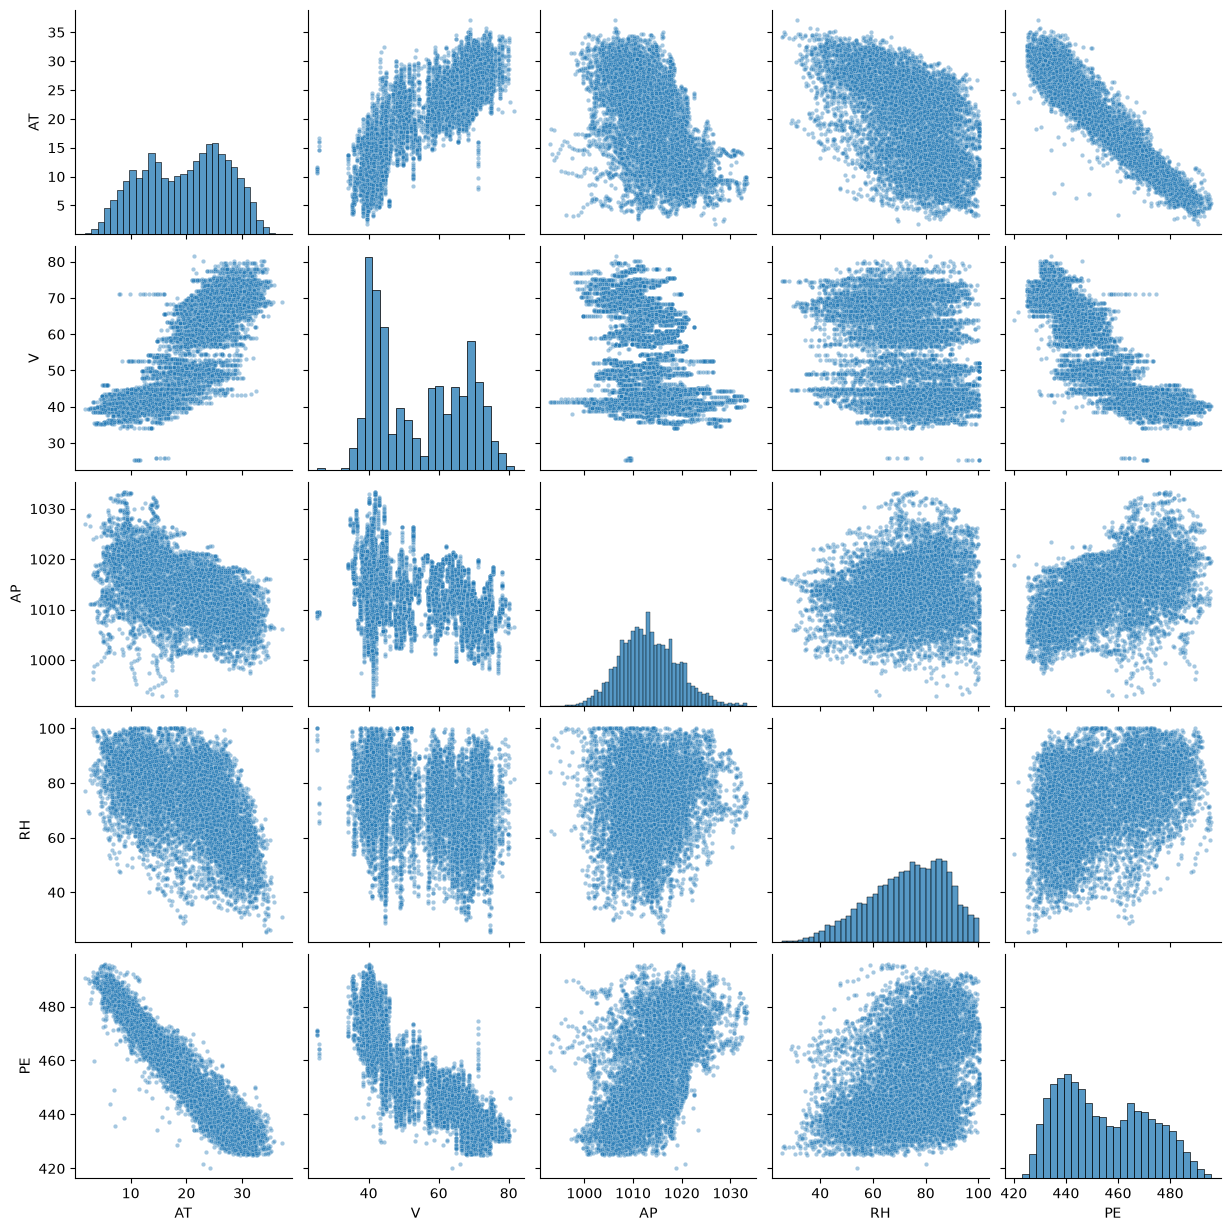

In [3]:
sns.pairplot(df, kind = "scatter", diag_kind = "hist", plot_kws = {"alpha": 0.4, "s": 10})
# I made the dots slightly transparent with alpha = 0.4 to make overlapping points more visible
plt.show()

##### The pairwise scatterplots above show that AT has a strong negative association with PE. The plots show that as ambient temperature increases, then the electrical energy output decreeases. It is also worth noting that as exhaust vacuum increases, the electrical energy output generally decreases but it doesn't have as strong of a relationship with PE as AT does. The rest of the variables have a moderate to weaker positive association with PE.

#### iii. Mean, Median, Range, First and Third Quartiles, Interquartile ranges of each of the variables in the data set (Summarize in a table)

In [4]:
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "First Quartile (Q1)": df.quantile(0.25),
    "Third Quartile (Q3)": df.quantile(0.75),
    "Interquartile Range (IQR)": df.quantile(0.75) - df.quantile(0.25)
})

summary_table.round(2)

,Mean,Median,Range,First Quartile (Q1),Third Quartile (Q3),Interquartile Range (IQR)
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression Model

In [5]:
import statsmodels.formula.api as smf

In [6]:
predictors = ["AT", "V", "AP", "RH"]

simple_models = {}
simple_results = []

In [7]:
for predictor in predictors:
    model = smf.ols(f"PE ~ {predictor}", data = df).fit()
    simple_models[predictor] = model

    simple_results.append({
        "Predictor": predictor,
        "Intercept": model.params["Intercept"],
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared
    })

simple_results_table = pd.DataFrame(simple_results)
simple_results_table.round(3)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.034,-2.171,0.0,0.899
1,V,517.802,-1.168,0.0,0.757
2,AP,-1055.261,1.490,0.0,0.269
3,RH,420.962,0.456,0.0,0.152


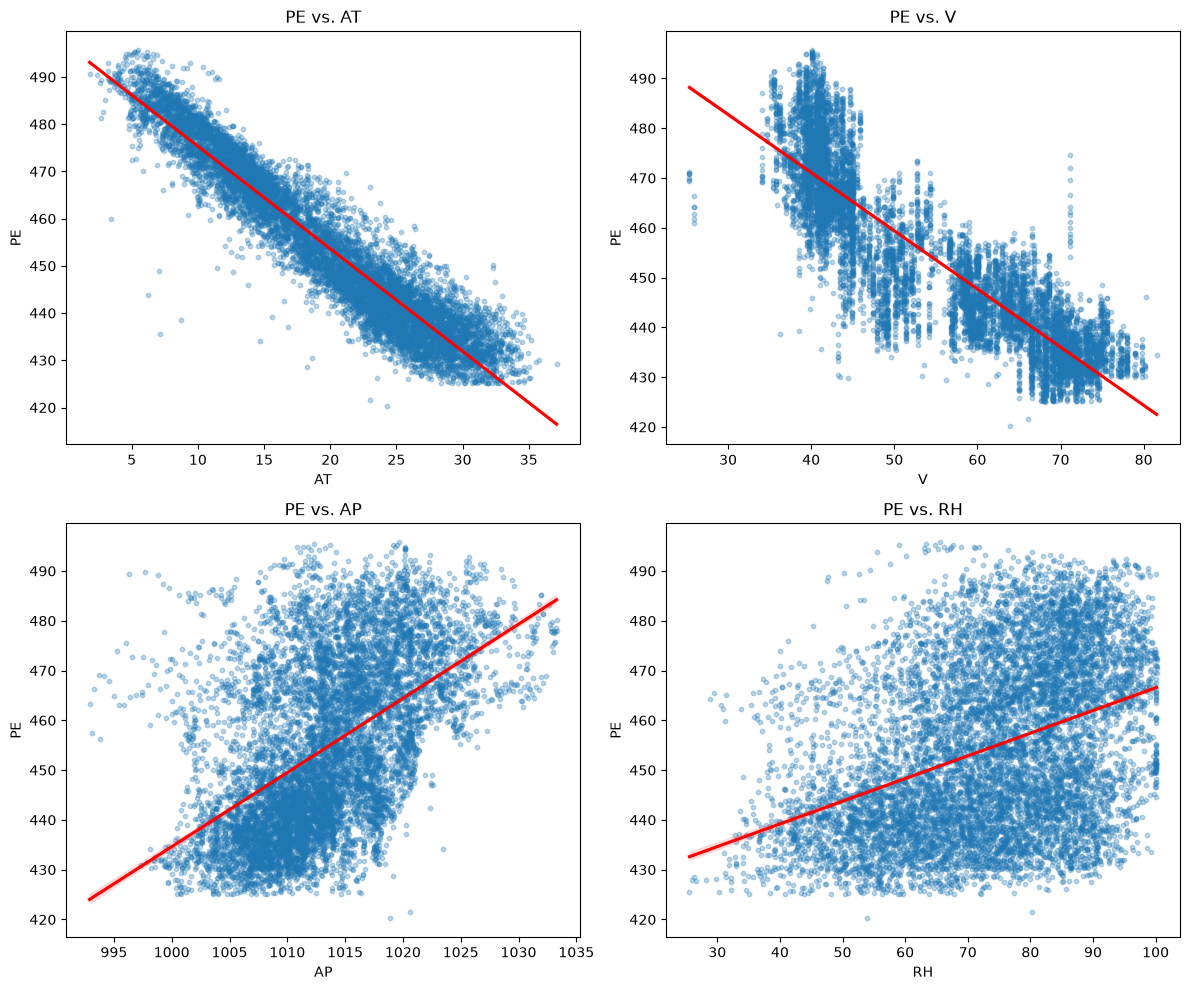

In [8]:
fig, axes = plt.subplots(2, 2, figsize = (12, 10))

for predictor, ax in zip(predictors, axes.flatten()):
    sns.regplot(
        data = df,
        x = predictor,
         y = "PE",
         ax = ax,
         scatter_kws = {"alpha": 0.3, "s": 10},
         line_kws = {"color": "red"}
    )

    ax.set_title(f"PE vs. {predictor}")

plt.tight_layout()
plt.show()

##### All 4 predictors have a p-value that is less than 0.001 so that makes them all statistically significant. There are a few points that deviate from the general trends but I wouldn't remove any observations and call them outliers without stronger evidence.
* AT: the strongest relationship with PE. For every one unit increase in AT, PE has a predicted decreased of about 2.171 units
* V: For every one unit increase in V, PE has a predicted decrease of about 1.168 units
* AP: has a weak positive relationship with PE
* RH: has the weakest relationship with PE

### (d) Multiple Regression model (use all of the predictors)

In [9]:
multiple_model = smf.ols("PE ~ AT + V + AP + RH", data = df).fit()

multiple_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:41:09   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.000     435.500     473.718
AT            -1.9775      0.015   -129.342      0.000      -2.007      -1.948
V             -0.2339      0.007    -32.122      0.000      -0.248      -0.220
AP             0.0621      0.009      6.564      0.000       0.044       0.081
RH            -0.1581      0.004    -37.918      0.000      -0.166      -0.150
==============================================================================
Omnibus:                      892.002   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4086.777
Skew:                          -0.352   Prob(JB):                         0.00
Kurtosis:                       6.123   Cond. No.                     2.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

##### The multiple linear regression model shows that about 92.9% of variation in PE ($R^2 = 0.929$). AT, V, and RH have negative associations with PE. AP has a positive association with PE. All 4 of the predictors have a p-value less than 0.001 so we reject the null hypothesis for all of them. All 4 predictors are statistically significant in the multiple regression model.

### (e) Plot using the univariate regerssion coefficients from 1c (x-axis) and the multiple regression coefficients from 1d (y-axis)

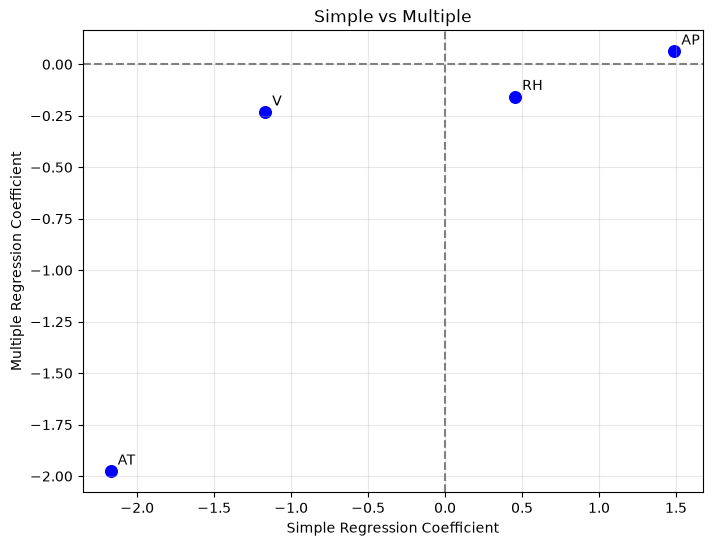

In [10]:
simple_coefficients = [
    simple_models[predictor].params[predictor]
    for predictor in predictors
]

multiple_coefficients = [
    multiple_model.params[predictor]
    for predictor in predictors
]

plt.figure(figsize = (8,6))
plt.scatter(simple_coefficients, multiple_coefficients, color = "blue", s = 70)

for predictor, x, y in zip(predictors, simple_coefficients, multiple_coefficients):
    plt.annotate(predictor, (x, y), xytext = (5, 5), textcoords = "offset points")

plt.axhline(0, color = "gray", linestyle = "--")
plt.axvline(0, color = "gray", linestyle = "--")

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple")
plt.grid(alpha = 0.3)
plt.show()

##### AT has similar negative coefficients in both of the models. The other 3 predictors (V, RH, AP), are much closer to 0 in the multiple regression model. In the simple regression model, RH changes from a positive coefficient to a negative coefficient in the multiple regression model. This is because the multiple regression model holds the other predictors constant as it estimates each predictor's relationship with PE.

### (f) Model for predictor X and Y = ...

In [11]:
polynomial_models = {}
polynomial_results = []

for predictor in predictors:
    formula = (
        f"PE ~ {predictor} +"
        f"I({predictor} ** 2) +"
        f"I({predictor} ** 3)"
    )

    model = smf.ols(formula, data = df).fit()
    polynomial_models[predictor] = model

    polynomial_results.append({
        "Predictor": predictor,
        "Linear p-value": model.pvalues.iloc[1],
        "Quadratic p-value": model.pvalues.iloc[2],
        "Cubic p-value": model.pvalues.iloc[3],
        "R-squared": model.rsquared
    })

polynomial_results_table = pd.DataFrame(polynomial_results)
polynomial_results_table.round(4)

C:\Users\tabor\AppData\Local\Temp\ipykernel_17696\845038215.py:11: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = smf.ols(formula, data = df).fit()


,Predictor,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,0.0000,0.0000,0.0000,0.9119
1,V,0.0000,0.7685,0.0137,0.7750
2,AP,0.0000,0.0000,0.0000,0.2749
3,RH,0.0004,0.0000,0.0000,0.1537


##### Yes, there is evidence of nonlinear association between each of predictors and PE. For AT, AP, and RH, the quadratic and cubic terms are statistically significant. The quadratic term is not significant (p = 0.7685) for V but the cubic term is signficiant with p = 0.0137. The cubic models provide evidence of nonlinearity for all 4 predictors.

### (g) Full Linear Regression Model with all Pairwise Interaction Terms

In [12]:
interaction_model = smf.ols( "PE ~ (AT + V + AP + RH) ** 2", data = df).fit()

interaction_terms = [term for term in interaction_model.params.index if ":" in term]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "P-Value": interaction_model.pvalues[interaction_terms]
})

interaction_results["Significant"] = (interaction_results["P-Value"] < 0.05)
print("R squared:", round(interaction_model.rsquared, 4))
interaction_results.round(4)

R squared: 0.9363


,Coefficient,P-Value,Significant
AT:V,0.0210,0.0000,True
AT:AP,0.0018,0.4521,False
AT:RH,-0.0052,0.0000,True
V:AP,0.0068,0.0000,True
V:RH,0.0008,0.0862,False
AP:RH,-0.0016,0.0336,True


##### Yes, there is evidence that some of the interactions of all of the predictors and PE. In the linear regrssion model with all the pairwise interactions, AT:V, AT:RH, V:AP, and AP:RH are statistically signficant because all of their p-values are less than 0.05. However, AT:AP and V:RH are not statistically significant because their p-values are greater than 0.05. The model has an $R^2$ of about 0.9363 which means it explains about 93.63% of variation of PE. 

### (h) Two Linear Regression models

#### Trained regression model on a randomly selected 70% subset of the data with all predicotrs

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_data, test_data = train_test_split(df, train_size = 0.70, random_state = 42)
linear_model = smf.ols("PE ~ AT + V + AP + RH", data = train_data).fit()

linear_train_predictions = linear_model.predict(train_data)
linear_test_predictions = linear_model.predict(test_data)

linear_train_mse = mean_squared_error(train_data["PE"], linear_train_predictions)
linear_test_mse = mean_squared_error(test_data["PE"], linear_test_predictions)

print("Linear model training MSE:", round(linear_train_mse, 4))
print("Linear model testing MSE: ", round(linear_test_mse, 4))

Linear model training MSE: 20.5808
Linear model testing MSE:  21.2399


#### Regression model with all possible interaction terms and quadratic nonlinearities (removed insignificant variables using p-values)

In [14]:
full_formula = """PE ~ AT + V + AP + RH + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2) + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"""

full_model = smf.ols(full_formula, data = train_data).fit()

full_results = pd.DataFrame({
    "Coeffificent": full_model.params,
    "P-Value": full_model.pvalues
})

full_results.round(4)

,Coeffificent,P-Value
Intercept,-7664.9809,0.0000
AT,-7.2885,0.0446
V,-1.9590,0.2672
AP,15.9308,0.0000
RH,3.9121,0.0001
I(AT ** 2),0.0185,0.0000
I(V ** 2),-0.0004,0.6998
I(AP ** 2),-0.0078,0.0000
I(RH ** 2),-0.0019,0.0000
AT:V,0.0095,0.0032


In [15]:
reduced_formula = """PE ~ AT + V + AP + RH + I(AT ** 2) + I(AP ** 2) + I(RH ** 2) + AT:V + AT:RH + AP:RH"""

reduced_model = smf.ols(reduced_formula, data = train_data).fit()

reduced_results = pd.DataFrame({
    "Coefficient": reduced_model.params,
    "P-Value": reduced_model.pvalues
})

reduced_train_predictions = reduced_model.predict(train_data)
reduced_test_predictions = reduced_model.predict(test_data)

reduced_train_mse = mean_squared_error(train_data["PE"], reduced_train_predictions)
reduced_test_mse = mean_squared_error(test_data["PE"], reduced_test_predictions)

print("Reduced model training MSE:", round(reduced_train_mse, 4))
print("Reduced model testing MSE:", round(reduced_test_mse, 4))

Reduced model training MSE: 17.9178
Reduced model testing MSE: 18.6943


##### Yes, you can improve the model like I did above by including significant quadratic and interaction terms. The original linear regression model had a training MSE of 20.5808 and a testing MSE of 21.2399. After removing the insignificant higher-order terms, the reduced model had a training MSE of 17.9178 and a testing MSE of 18.6943. and the newer model reduced to an MSE of 17.9178. Both MSE values decreased then this implies that the quadratic and interaction terms improved the model's predictive performance.

### (i) KNN Regression

#### i. K-Nearest Neighbor Regression

In [16]:
from sklearn.neighbors import KNeighborsRegressor

features = ["AT", "V", "AP", "RH"]

X_train = train_data[features]
y_train = train_data["PE"]
X_test = test_data[features]
y_test = test_data["PE"]

k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors = k)
    knn_model.fit(X_train, y_train)

    raw_train_predictions = knn_model.predict(X_train)
    raw_test_predictions = knn_model.predict(X_test)

    raw_train_mse.append(mean_squared_error(y_train, raw_train_predictions))
    raw_test_mse.append(mean_squared_error(y_test, raw_test_predictions))

best_raw_k = list(k_values)[raw_test_mse.index(min(raw_test_mse))]

print("Best k for raw features:", best_raw_k)
print("Lowest raw features testing MSE", round(min(raw_test_mse), 4))

Best k for raw features: 5
Lowest raw features testing MSE 15.7268


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    knn_model = KNeighborsRegressor(n_neighbors = k)
    knn_model.fit(X_train_normalized, y_train)

    normalized_train_predictions = knn_model.predict(X_train_normalized)
    normalized_test_predictions = knn_model.predict(X_test_normalized)

    normalized_train_mse.append(mean_squared_error(y_train, normalized_train_predictions))
    normalized_test_mse.append(mean_squared_error(y_test, normalized_test_predictions))

best_normalized_k = list(k_values)[normalized_test_mse.index(min(normalized_test_mse))]

print("Best k for normalized features:", best_normalized_k)
print("Lowest normalized-feature testing MSE:", round(min(normalized_test_mse), 4))


Best k for normalized features: 4
Lowest normalized-feature testing MSE: 14.3057


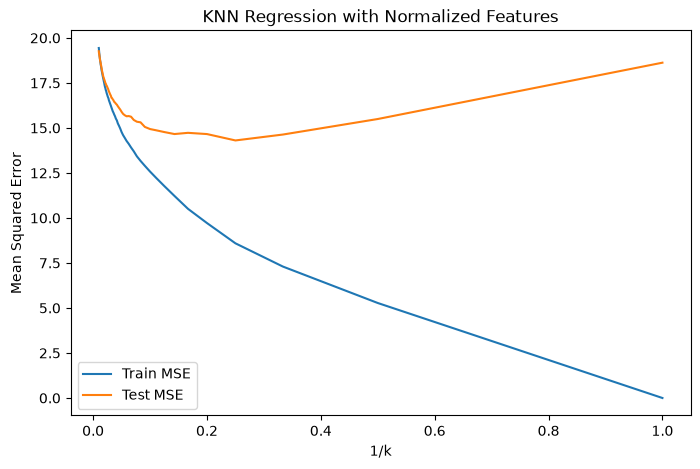

In [18]:
import numpy as np

plt.figure(figsize=(8, 5))

plt.plot(1 / np.array(k_values), normalized_train_mse, label='Train MSE')
plt.plot(1 / np.array(k_values), normalized_test_mse, label='Test MSE')

plt.xlabel('1/k')
plt.ylabel('Mean Squared Error')
plt.title('KNN Regression with Normalized Features')
plt.legend()

plt.show()

### (j) Compare KNN Regression with Linear Regression

##### The best KNN regression model used normalized features with $k=4$ and had a test MSE of 14.3057. The reduced linear regression model had a test MSE of 18.6943. Since the KNN model has the lower test MSE, it performed better on the test data. This suggests that KNN was able to capture relationships in the data that were not fully captured by the linear regression model.